<a href="https://colab.research.google.com/github/oktennant-del/CUNY---DC37--Data-Analytics-Academy/blob/main/DC37_Data__Analytics_Capstone_Project_May_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Salary Patterns in NYC Public Service
### DC37 Data Analytics Academy Capstone Project (2026)
**Author:** Oronde Tennant

## Overview
This project examines salary patterns across NYC public service employees, focusing on how **job title**, **agency**, **education**, and **demographic factors** influence compensation.  

## Research Questions
- How do title, agency, and education affect salary?
- Are there demographic disparities in compensation?
- What patterns emerge across the workforce?

## Data Sources
This project uses publicly available datasets from **NYC Open Data**, supplemented with demographic and education‑related sources.

Primary datasets:
- **Citywide Payroll Data (Fiscal Year)**  
- **Civil Service Titles**
- **Position Schedule (Min/Max Salary by Title)**
- **Workforce Demographics (EEO)**
- **City Agency Directory**

## Methodology
### Tools
Python, Pandas, NumPy, Seaborn, Matplotlib.

### Data Cleaning
- Standardizing job titles  
- Converting salary fields to numeric  
- Handling missing values  

### Transformations
- Salary bands (quartiles)  
- Tenure categories  
- Merged demographic indicators  

### Statistical Methods
- Descriptive statistics  
- Correlation or ANOVA  
- Regression (optional extension)

## Visualizations
The notebook includes visuals to capture the following:
1. Salary Distribution  
2. Median Salary by Job Title  
3. Salary Ranges by Agency  
4. Salary by Education Level  
5. Demographic Representation in Top‑Paying Titles  
6. Agency Salary Variability vs. Average Salary  

## Findings & Insights
- Titles with highest/lowest median salaries  
- Agencies with widest salary ranges  
- Education level correlation  
- Demographic disparities  
- Unexpected findings  

## Conclusion
Salary outcomes in NYC public service are shaped by structural factors — title, agency, education, and demographics.  
**Recommendation:** Standardize salary bands across agencies for comparable titles.



In [29]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. LOAD ALL DATASETS
# ---------------------------------------------------------

payroll = pd.read_csv("/content/Capstone_Project_20260515.csv", low_memory=False)
titles = pd.read_csv("/content/Civil_Service_List_(Active)_20260515.csv")
# demographics = pd.read_csv("workforce_demographics.csv")
position_schedule = pd.read_csv("/content/Position_Schedule_20260515.csv")
# agencies = pd.read_csv("agency_directory.csv")

# ---------------------------------------------------------
# 2. STANDARDIZE COLUMN NAMES
# ---------------------------------------------------------

def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

payroll = clean_columns(payroll)
titles = clean_columns(titles)
position_schedule = clean_columns(position_schedule)
# demographics = clean_columns(demographics)
# agencies = clean_columns(agencies)

# ---------------------------------------------------------
# 3. CLEAN PAYROLL DATA
# ---------------------------------------------------------

salary_cols = ["base_salary", "regular_gross_paid", "total_ot_paid", "total_other_pay", "regular_hours"]
for col in salary_cols:
    if col in payroll.columns:
        # Remove non-numeric characters like '$' and ',' before converting to numeric
        payroll[col] = payroll[col].astype(str).str.replace(r'[$,]', '', regex=True)
        payroll[col] = pd.to_numeric(payroll[col], errors="coerce")

if "regular_gross_paid" in payroll.columns:
    payroll["annual_salary"] = payroll["regular_gross_paid"]
elif "base_salary" in payroll.columns:
    payroll["annual_salary"] = payroll["base_salary"]

if "title_description" in payroll.columns:
    payroll["title"] = payroll["title_description"].str.title()
elif "title" in payroll.columns:
    payroll["title"] = payroll["title"].str.title()

if "agency" in payroll.columns:
    payroll["agency"] = payroll["agency"].str.upper()

# ---------------------------------------------------------
# 4. MERGE: PAYROLL + TITLES
# ---------------------------------------------------------

title_key = "title_code" if "title_code" in payroll.columns else "civil_service_title_code"

if title_key in payroll.columns and title_key in titles.columns:
    merged = payroll.merge(
        titles,
        how="left",
        left_on=title_key,
        right_on=title_key,
        suffixes=("", "_title")
    )
else:
    merged = payroll.copy()

# ---------------------------------------------------------
# 5. MERGE: PAYROLL + POSITION SCHEDULE
# ---------------------------------------------------------

if "title_code" in merged.columns and "title_code" in position_schedule.columns:
    merged = merged.merge(
        position_schedule,
        how="left",
        on="title_code",
        suffixes=("", "_schedule")
    )

# ---------------------------------------------------------
# 6. MERGE: PAYROLL + AGENCY DIRECTORY
# ---------------------------------------------------------

# if "agency" in merged.columns and "agency_code" in agencies.columns:
#     merged = merged.merge(
#         agencies,
#         how="left",
#         left_on="agency",
#         right_on="agency_code",
#         suffixes=("", "_agency")
#     )

# ---------------------------------------------------------
# 7. MERGE: PAYROLL + DEMOGRAPHICS
# ---------------------------------------------------------

# if "agency" in merged.columns and "agency" in demographics.columns:
#     merged = merged.merge(
#         demographics,
#         how="left",
#         on="agency",
#         suffixes=("", "_demo")
#     )

# ---------------------------------------------------------
# 8. FINAL CLEANUP
# ---------------------------------------------------------

merged = merged.drop_duplicates()
merged = merged[merged["annual_salary"].notna()]

merged["salary_band"] = pd.qcut(
    merged["annual_salary"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"],
    duplicates='drop'
)

print("Final merged dataset shape:", merged.shape)
merged.head()

Final merged dataset shape: (562896, 20)


,fiscal_year,payroll_number,agency_name,last_name,first_name,mid_init,agency_start_date,work_location_borough,title_description,leave_status_as_of_june_30,base_salary,pay_basis,regular_hours,regular_gross_paid,ot_hours,total_ot_paid,total_other_pay,annual_salary,title,salary_band
0,2024,67,ADMIN FOR CHILDREN'S SVCS,ALEXANDER,SHATON,E,06/20/2023,BRONX,CHILD PROTECTIVE SPECIALIST,ACTIVE,67899.0,per Annum,1810.0,65206.02,84.5,3566.62,4468.91,65206.02,Child Protective Specialist,Mid-High
1,2024,67,ADMIN FOR CHILDREN'S SVCS,DELICE-SHEPPARD,MARIE,M,08/21/2006,QUEENS,CHILD PROTECTIVE SPECIALIST SUPERVISOR,ON LEAVE,96925.0,per Annum,1610.0,82778.11,223.75,13664.67,4465.97,82778.11,Child Protective Specialist Supervisor,Mid-High
2,2024,67,ADMIN FOR CHILDREN'S SVCS,MALDONADO,JEANINE,M,10/24/2011,QUEENS,CHILD PROTECTIVE SPECIALIST,ACTIVE,67899.0,per Annum,1820.0,65567.23,0,0.00,4464.60,65567.23,Child Protective Specialist,Mid-High
3,2024,67,ADMIN FOR CHILDREN'S SVCS,PADILLA,MILAGROS,NaN,02/13/2012,BRONX,CHILD PROTECTIVE SPECIALIST SUPERVISOR,ACTIVE,75850.0,per Annum,1820.0,79937.88,127.25,6718.10,4463.93,79937.88,Child Protective Specialist Supervisor,Mid-High
4,2024,67,ADMIN FOR CHILDREN'S SVCS,BRAITHWAITE-CRA,SHIRLEY,E,08/05/2013,BROOKLYN,CHILD PROTECTIVE SPECIALIST,ACTIVE,67899.0,per Annum,1810.0,65206.13,144.5,6701.26,4463.71,65206.13,Child Protective Specialist,Mid-High


In [17]:
# Check for missing values in 'annual_salary'
missing_annual_salary = merged['annual_salary'].isnull().sum()
percentage_missing_annual_salary = (missing_annual_salary / len(merged)) * 100

print(f"Number of missing values in 'annual_salary': {missing_annual_salary}")
print(f"Percentage of missing values in 'annual_salary': {percentage_missing_annual_salary:.2f}%")

Number of missing values in 'annual_salary': 0
Percentage of missing values in 'annual_salary': 0.00%


In [20]:
top_titles_by_salary_band = merged.groupby('salary_band', observed=True)['title'].value_counts().groupby(level=0).head(5)
display(top_titles_by_salary_band)

/tmp/ipykernel_5432/1781067416.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_titles_by_salary_band = merged.groupby('salary_band', observed=True)['title'].value_counts().groupby(level=0).head(5)


salary_band  title                    
Low          Teacher- Per Session         54791
             Election Worker              27305
             Teacher-General Ed            5850
             Teacher                       4193
             Student Aide                  3302
Mid-Low      Teacher- Per Session         29429
             Annual Ed Para               13211
             Substitute Ed Para            9633
             Teacher-General Ed            9489
             Police Officer                7542
Mid-High     Teacher                      14073
             Annual Ed Para               13149
             Teacher Special Education    10951
             Police Officer                8668
             Sanitation Worker             6652
High         Teacher                      35692
             Teacher Special Education    15673
             Police Officer               12410
             Firefighter                   5973
             Sergeant-                     3892
Name: count, dtype: int64

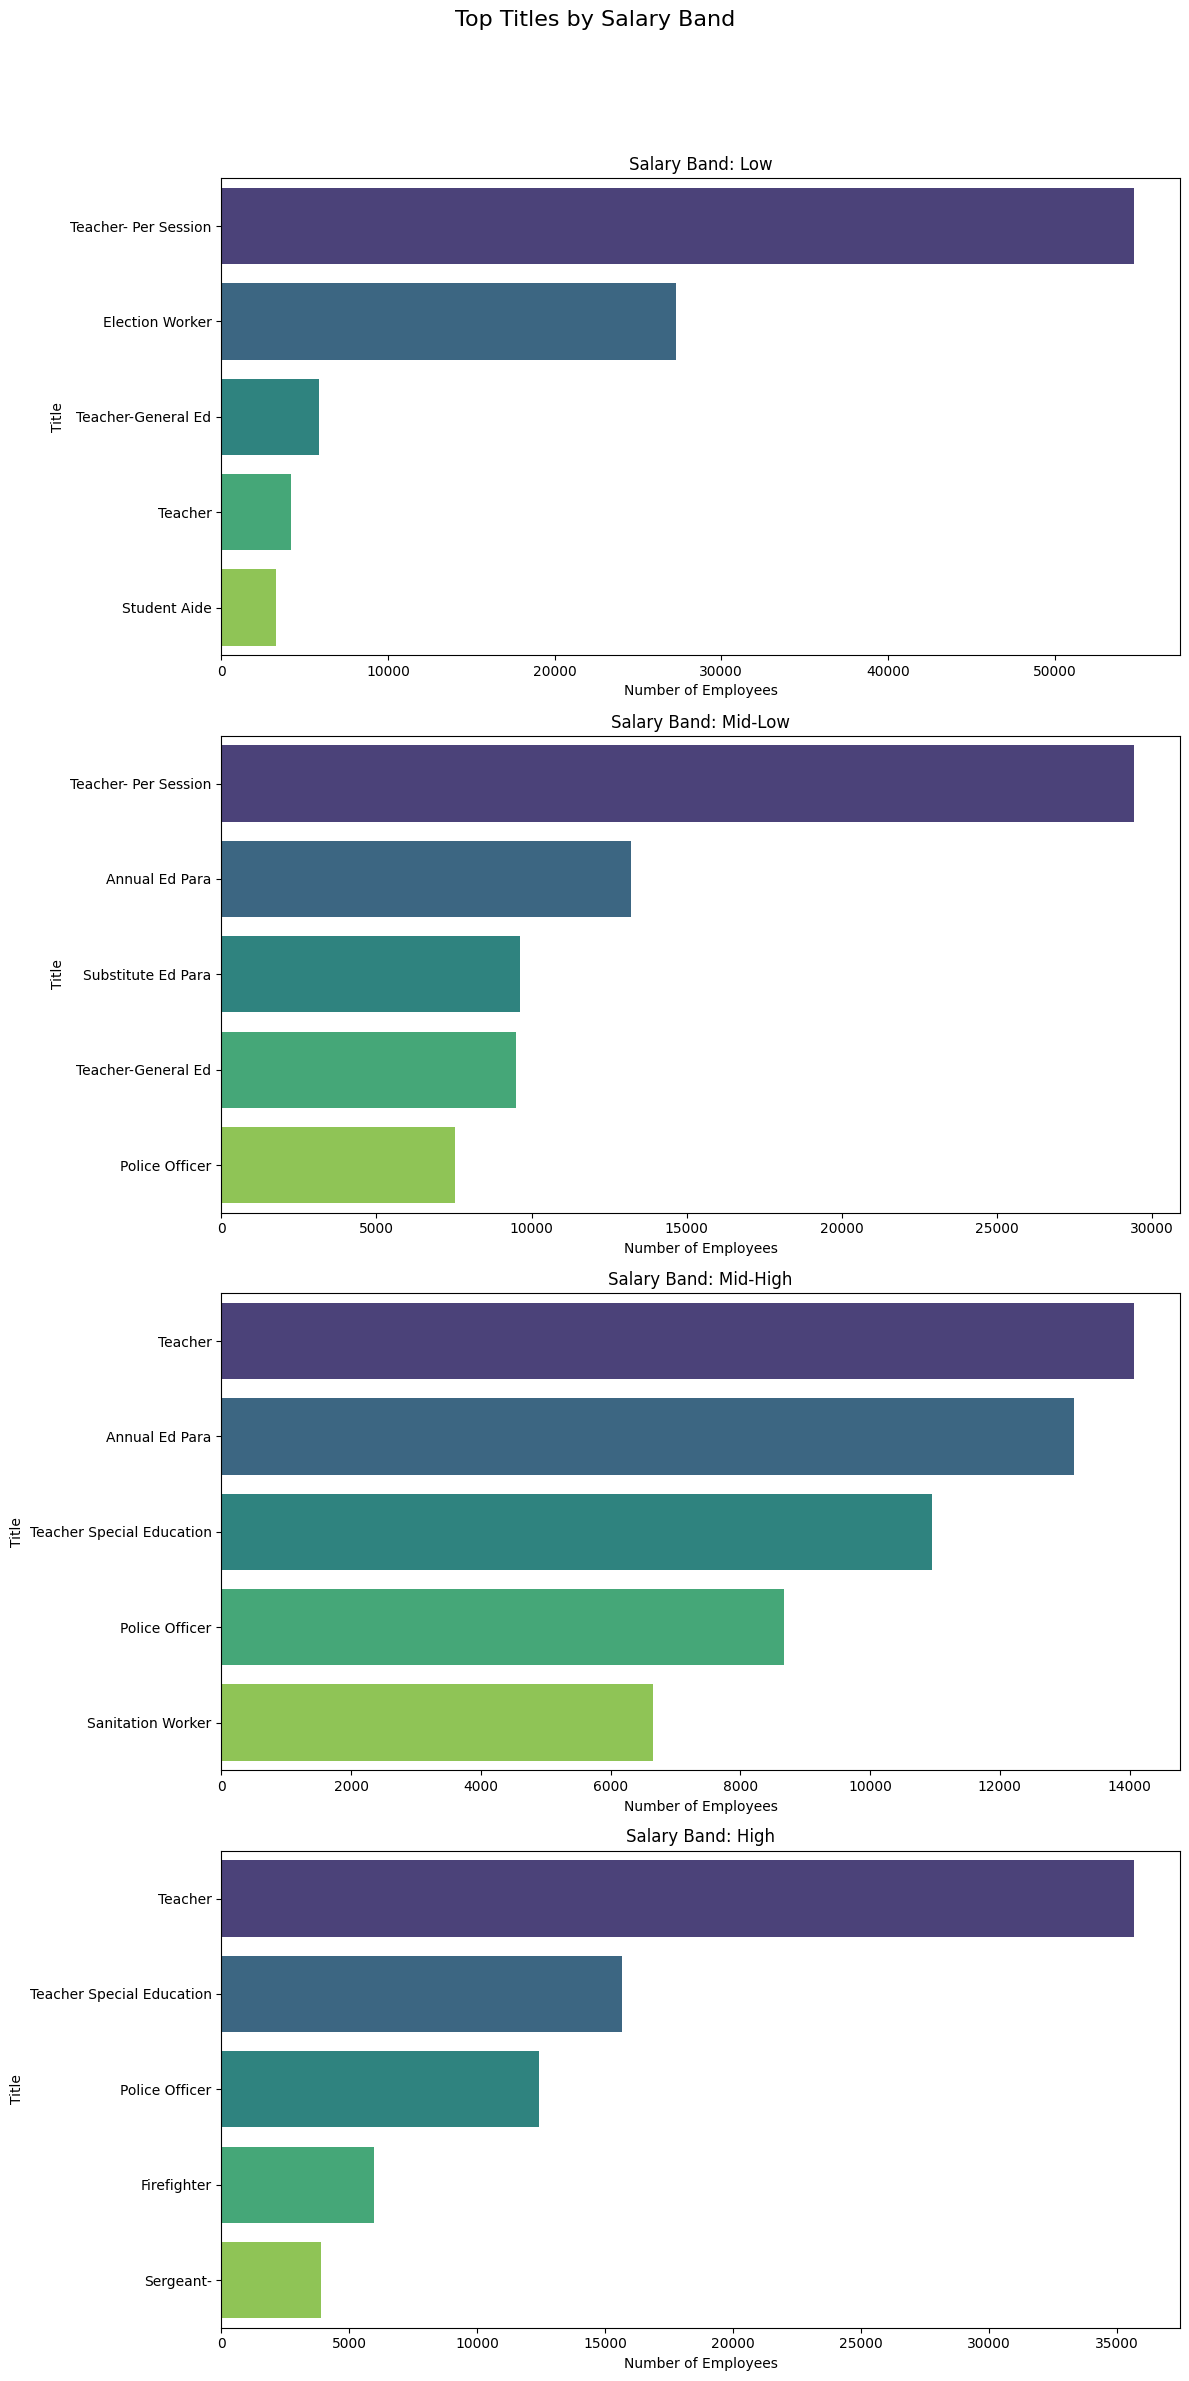

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the Series to a DataFrame for easier plotting
top_titles_df = top_titles_by_salary_band.reset_index()
# The value column is named 'count' by default after reset_index() if the Series is unnamed
# top_titles_df.rename(columns={0: 'num_employees'}, inplace=True) # This line is incorrect, as the column is already named 'count'

# Get unique salary bands
salary_bands = top_titles_df['salary_band'].unique()

# Create a figure with subplots for each salary band
fig, axes = plt.subplots(nrows=len(salary_bands), figsize=(12, 6 * len(salary_bands)))
fig.suptitle('Top Titles by Salary Band', y=1.02, fontsize=16)

for i, band in enumerate(salary_bands):
    ax = axes[i] if len(salary_bands) > 1 else axes
    band_data = top_titles_df[top_titles_df['salary_band'] == band].sort_values(by='count', ascending=False)

    sns.barplot(x='count', y='title', data=band_data, ax=ax, palette='viridis', hue='title', legend=False)
    ax.set_title(f'Salary Band: {band}')
    ax.set_xlabel('Number of Employees')
    ax.set_ylabel('Title')
    ax.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

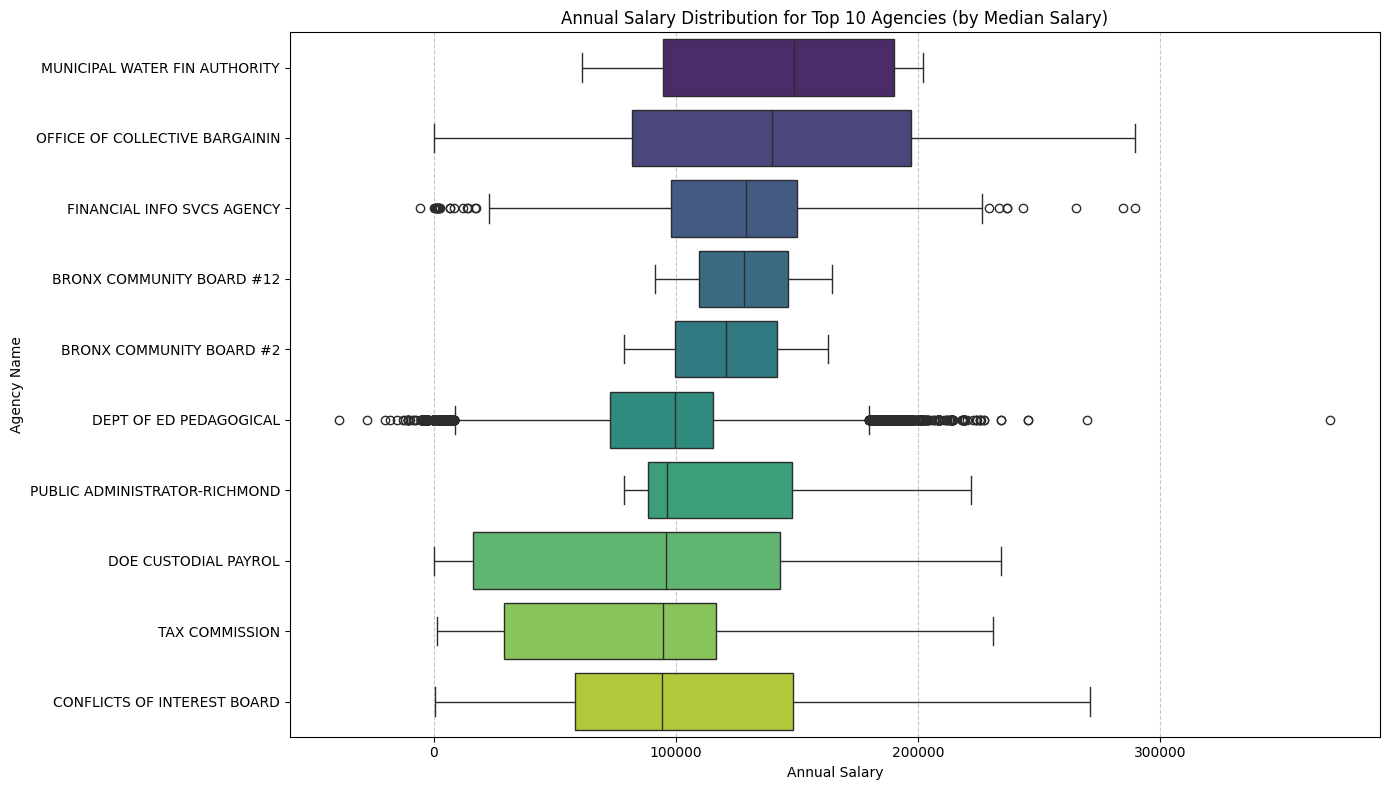

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the median annual salary for each agency
agency_median_salary = merged.groupby('agency_name')['annual_salary'].median().sort_values(ascending=False)

# Select the top 10 agencies based on median salary for better visualization
top_10_agencies = agency_median_salary.head(10).index

# Filter the merged DataFrame to include only these top agencies
df_top_agencies = merged[merged['agency_name'].isin(top_10_agencies)].copy()

# Ensure the agency_name is a categorical type with the order of median salaries
df_top_agencies['agency_name'] = pd.Categorical(df_top_agencies['agency_name'], categories=top_10_agencies, ordered=True)

# Create the boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(x='annual_salary', y='agency_name', data=df_top_agencies, palette='viridis', hue='agency_name', legend=False)
plt.title('Annual Salary Distribution for Top 10 Agencies (by Median Salary)')
plt.xlabel('Annual Salary')
plt.ylabel('Agency Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

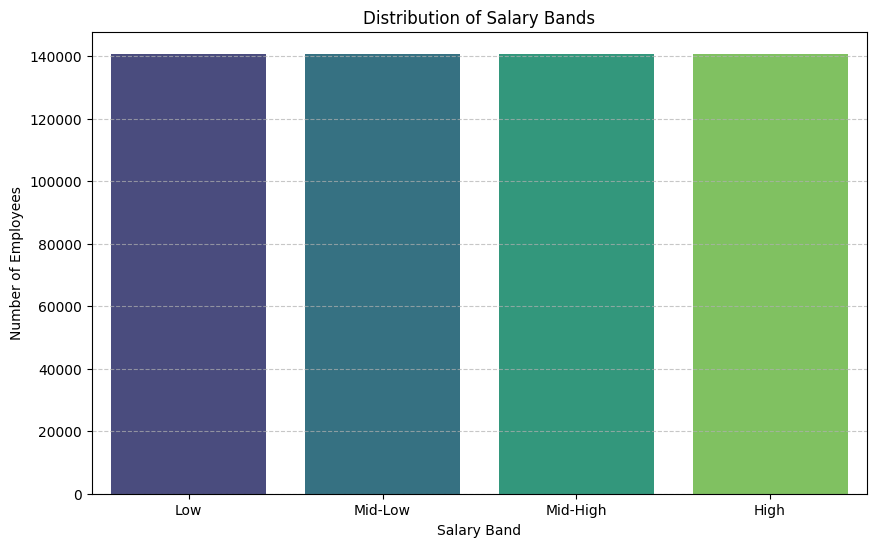

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution of salary bands
salary_band_distribution = merged['salary_band'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=salary_band_distribution.index, y=salary_band_distribution.values, palette='viridis', hue=salary_band_distribution.index, legend=False)
plt.title('Distribution of Salary Bands')
plt.xlabel('Salary Band')
plt.ylabel('Number of Employees')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

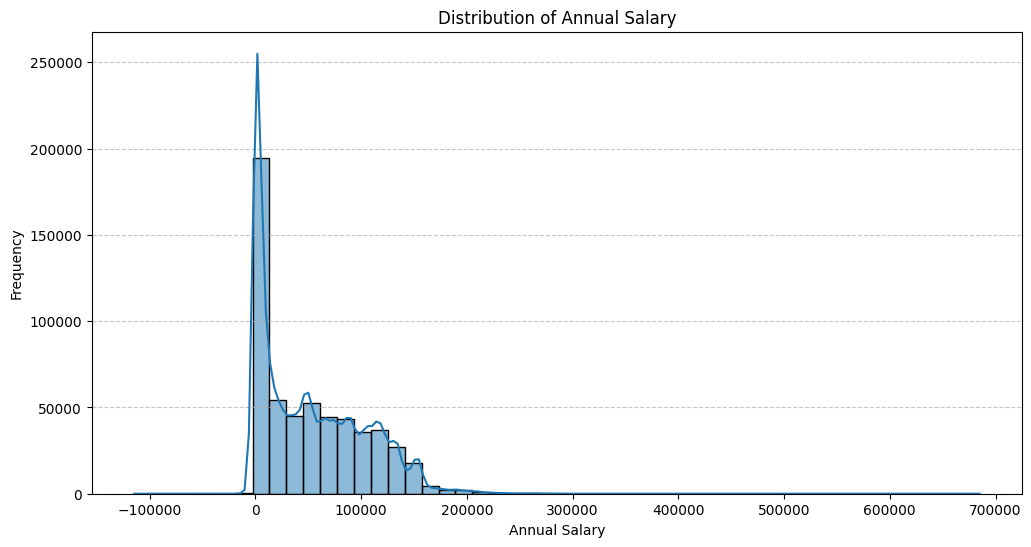

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(merged['annual_salary'], bins=50, kde=True)
plt.title('Distribution of Annual Salary')
plt.xlabel('Annual Salary')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis
plt.show()

In [19]:
top_5_titles = merged.groupby('title')['annual_salary'].mean().nlargest(5)
display(top_5_titles)

,annual_salary
title,
Chancellor,370411.33
Chief Actuary,335776.38
First Deputy Mayor,301242.46
Director Of Management & Budget,299577.07
Commissioner Of Labor Relations,289850.80


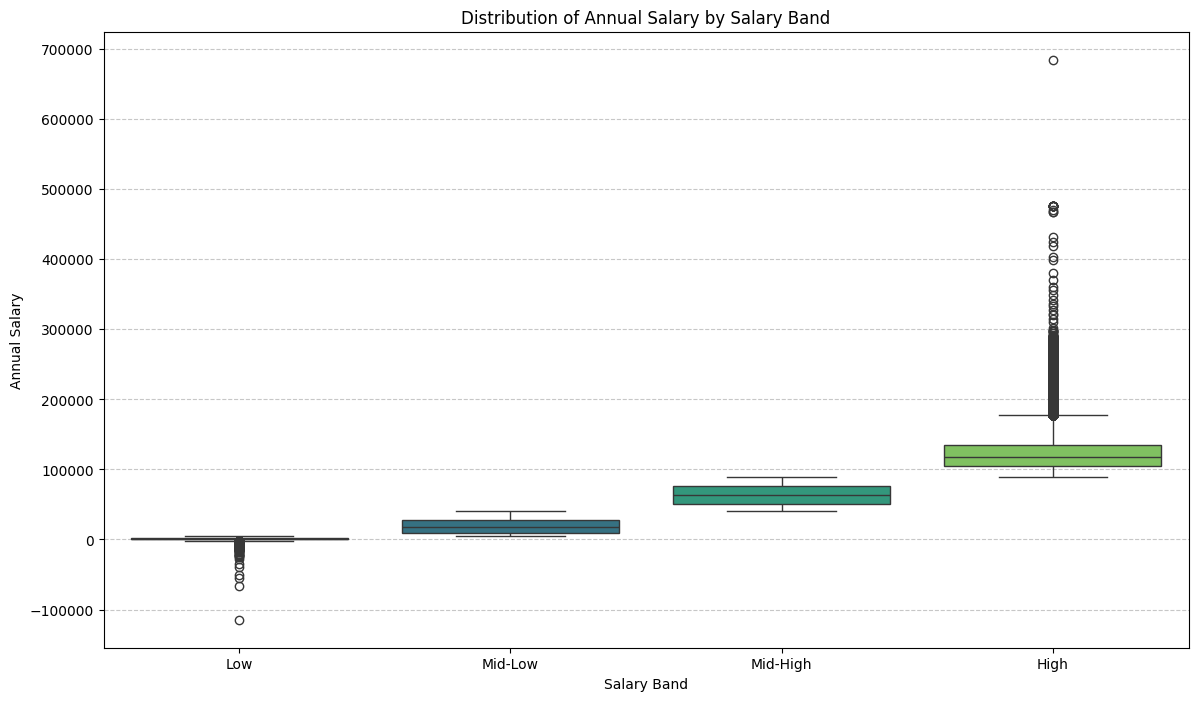

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.boxplot(x='salary_band', y='annual_salary', data=merged, palette='viridis', hue='salary_band', legend=False)
plt.title('Distribution of Annual Salary by Salary Band')
plt.xlabel('Salary Band')
plt.ylabel('Annual Salary')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.show()

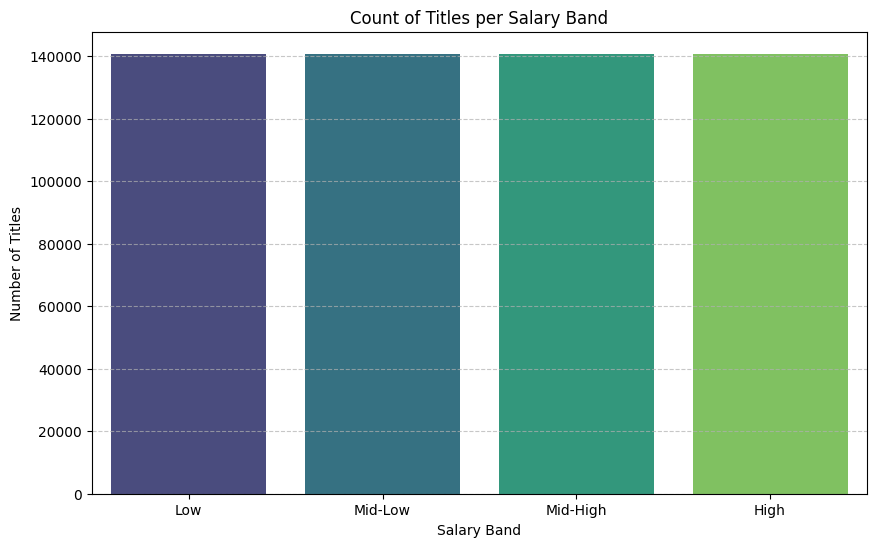

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution of salary bands (if not already calculated)
salary_band_distribution = merged['salary_band'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=salary_band_distribution.index, y=salary_band_distribution.values, palette='viridis', hue=salary_band_distribution.index, legend=False)
plt.title('Count of Titles per Salary Band')
plt.xlabel('Salary Band')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [23]:
num_unique_agencies = merged['agency_name'].nunique()
print(f"Number of unique agencies: {num_unique_agencies}")

Number of unique agencies: 159


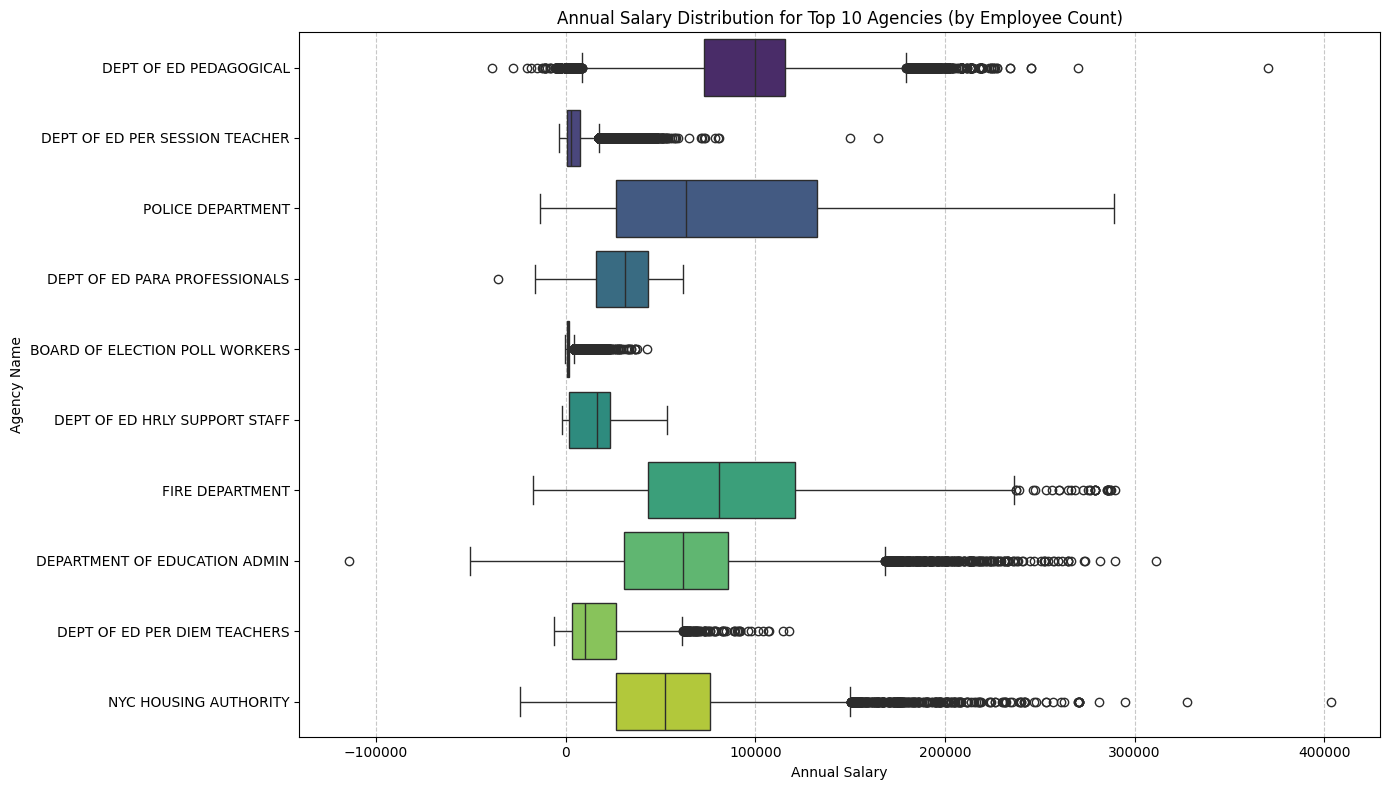

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of employees per agency
agency_employee_counts = merged['agency_name'].value_counts()

# Select the top 10 agencies based on employee count
top_10_agencies_by_employees = agency_employee_counts.head(10).index

# Filter the merged DataFrame to include only these top agencies
df_top_agencies_by_employees = merged[merged['agency_name'].isin(top_10_agencies_by_employees)].copy()

# Ensure the agency_name is a categorical type with the order of employee counts
df_top_agencies_by_employees['agency_name'] = pd.Categorical(
    df_top_agencies_by_employees['agency_name'],
    categories=top_10_agencies_by_employees,
    ordered=True
)

# Create the boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(
    x='annual_salary',
    y='agency_name',
    data=df_top_agencies_by_employees,
    palette='viridis',
    hue='agency_name',
    legend=False
)
plt.title('Annual Salary Distribution for Top 10 Agencies (by Employee Count)')
plt.xlabel('Annual Salary')
plt.ylabel('Agency Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

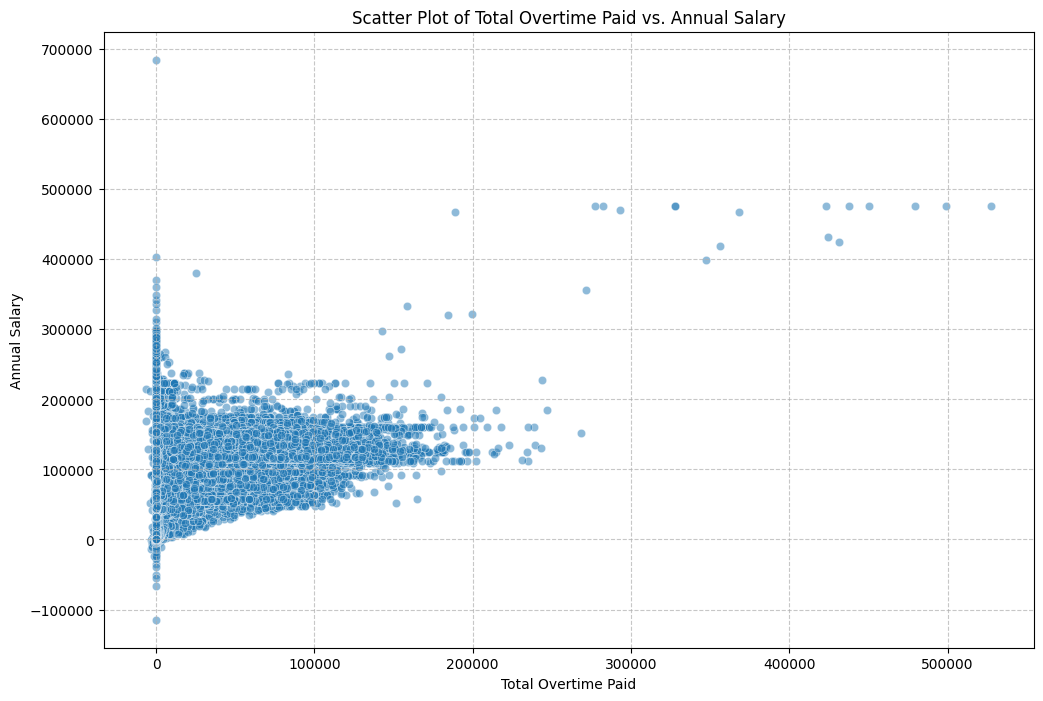

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(x='total_ot_paid', y='annual_salary', data=merged, alpha=0.5)
plt.title('Scatter Plot of Total Overtime Paid vs. Annual Salary')
plt.xlabel('Total Overtime Paid')
plt.ylabel('Annual Salary')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [26]:
correlation = merged['total_ot_paid'].corr(merged['annual_salary'])
print(f"Correlation between Total Overtime Paid and Annual Salary: {correlation:.2f}")

Correlation between Total Overtime Paid and Annual Salary: 0.39


In [30]:
import statsmodels.api as sm

# Define the new independent variables (X) and dependent variable (y)
X_new = merged[['total_ot_paid', 'regular_hours', 'total_other_pay']]
y = merged['annual_salary']

# Drop rows with NaN values in the independent variables after cleaning
X_new = X_new.dropna()
y_cleaned = y[X_new.index] # Ensure y aligns with cleaned X

# Add a constant to the independent variables for the intercept
X_new = sm.add_constant(X_new)

# Create and fit the OLS (Ordinary Least Squares) regression model with new variables
model_new = sm.OLS(y_cleaned, X_new)
results_new = model_new.fit()

# Print the regression summary for the updated model
print(results_new.summary())

                            OLS Regression Results                            
Dep. Variable:          annual_salary   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                 1.259e+05
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        06:13:25   Log-Likelihood:            -6.7417e+06
No. Observations:              562896   AIC:                         1.348e+07
Df Residuals:                  562892   BIC:                         1.348e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.623e+04     67.424    3

In [35]:
import statsmodels.api as sm

# Define the independent variables (X) and dependent variable (y) again
X_new = merged[['total_ot_paid', 'regular_hours', 'total_other_pay']]
y = merged['annual_salary']

# Drop rows with NaN values in the independent variables to match the OLS data
X_new = X_new.dropna()
y_cleaned = y[X_new.index] # Ensure y aligns with cleaned X

# Add a constant to the independent variables for the intercept
X_new = sm.add_constant(X_new)

# Create and fit the Robust Linear Model (RLM) with HuberT estimator
# The HuberT method is a common choice for robust regression, less sensitive to outliers
rlm_model = sm.RLM(y_cleaned, X_new, M=sm.robust.norms.HuberT())
rlm_results = rlm_model.fit()

# Print the robust regression summary
print(rlm_results.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:          annual_salary   No. Observations:               562896
Model:                            RLM   Df Residuals:                   562892
Method:                          IRLS   Df Model:                            3
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Fri, 15 May 2026                                         
Time:                        06:35:54                                         
No. Iterations:                    22                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1.496e+04     46.405    3

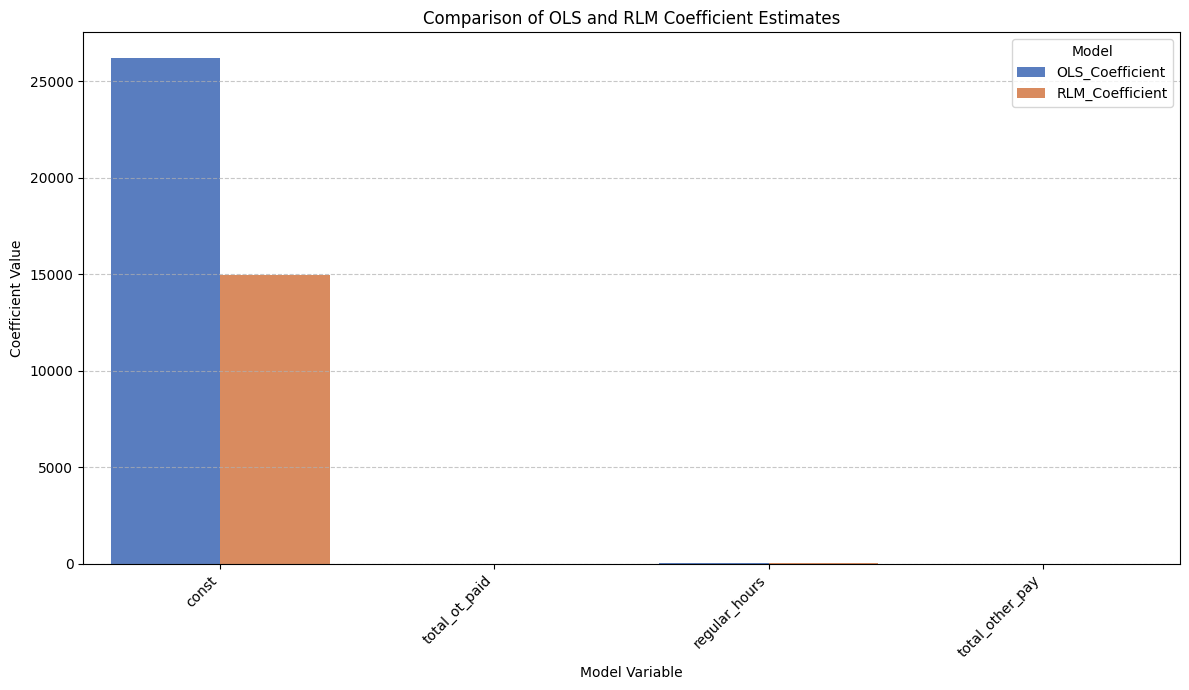

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract coefficients from OLS model
ols_coefs = results_new.params

# Extract coefficients from RLM model
rlm_coefs = rlm_results.params

# Create a DataFrame to compare coefficients
coef_comparison = pd.DataFrame({
    'OLS_Coefficient': ols_coefs,
    'RLM_Coefficient': rlm_coefs
})

# Filter for common variables, excluding intercept for some plots if desired, but here we include all
common_vars = ['const', 'total_ot_paid', 'regular_hours', 'total_other_pay']
coef_comparison = coef_comparison.loc[common_vars]

# Reshape for plotting with seaborn
coef_comparison_melted = coef_comparison.reset_index().melt(id_vars='index', var_name='Model', value_name='Coefficient')
coef_comparison_melted.rename(columns={'index': 'Variable'}, inplace=True)

# Create the grouped bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Variable', y='Coefficient', hue='Model', data=coef_comparison_melted, palette='muted')
plt.title('Comparison of OLS and RLM Coefficient Estimates')
plt.xlabel('Model Variable')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

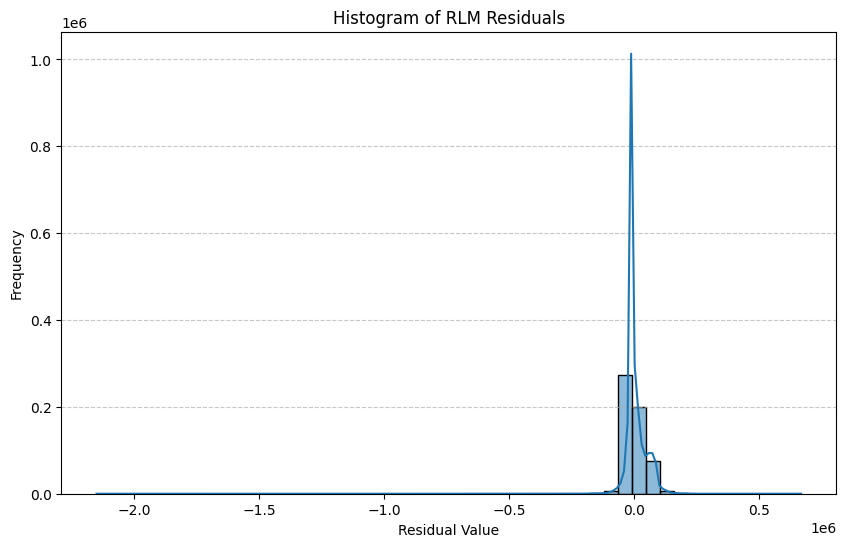

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Extract residuals from the RLM model results
rlm_residuals = rlm_results.resid

# Plotting the histogram of RLM residuals
plt.figure(figsize=(10, 6))
sns.histplot(rlm_residuals, kde=True, bins=50)
plt.title('Histogram of RLM Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Figure size 800x600 with 0 Axes>

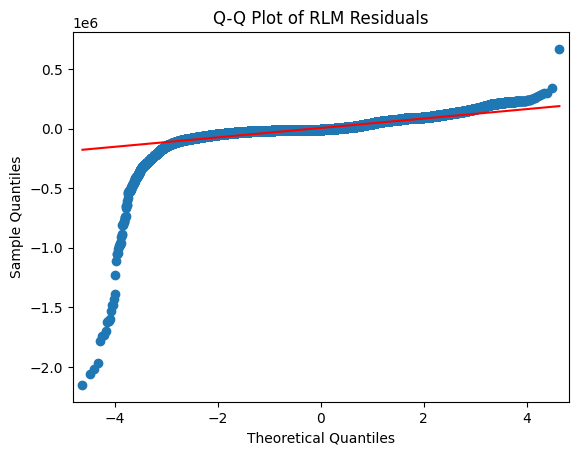

In [38]:
# Plotting the Q-Q plot of RLM residuals
plt.figure(figsize=(8, 6))
sm.qqplot(rlm_residuals, line='s') # 's' for standardized line
plt.title('Q-Q Plot of RLM Residuals')
plt.show()

In [39]:
# Filter the top_titles_by_salary_band to show only those in the 'High' salary band
top_titles_high_salary_band = top_titles_by_salary_band.loc['High']

# Display the results
print("Top-Paying Job Titles (High Salary Band):")
display(top_titles_high_salary_band)

Top-Paying Job Titles (High Salary Band):


,count
title,
Teacher,35692
Teacher Special Education,15673
Police Officer,12410
Firefighter,5973
Sergeant-,3892


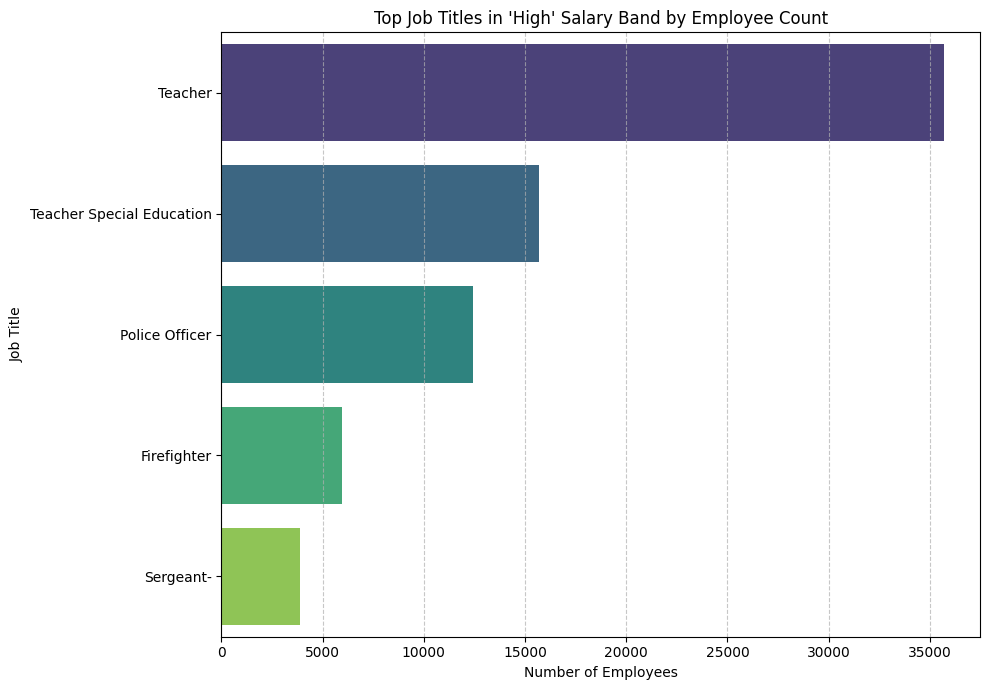

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'top_titles_high_salary_band' is a Pandas Series from previous output
# Convert to DataFrame for easier plotting with seaborn
top_titles_high_df = top_titles_high_salary_band.reset_index()
top_titles_high_df.columns = ['Title', 'Count']

plt.figure(figsize=(10, 7))
sns.barplot(x='Count', y='Title', data=top_titles_high_df, palette='viridis', hue='Title', legend=False)
plt.title('Top Job Titles in \'High\' Salary Band by Employee Count')
plt.xlabel('Number of Employees')
plt.ylabel('Job Title')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

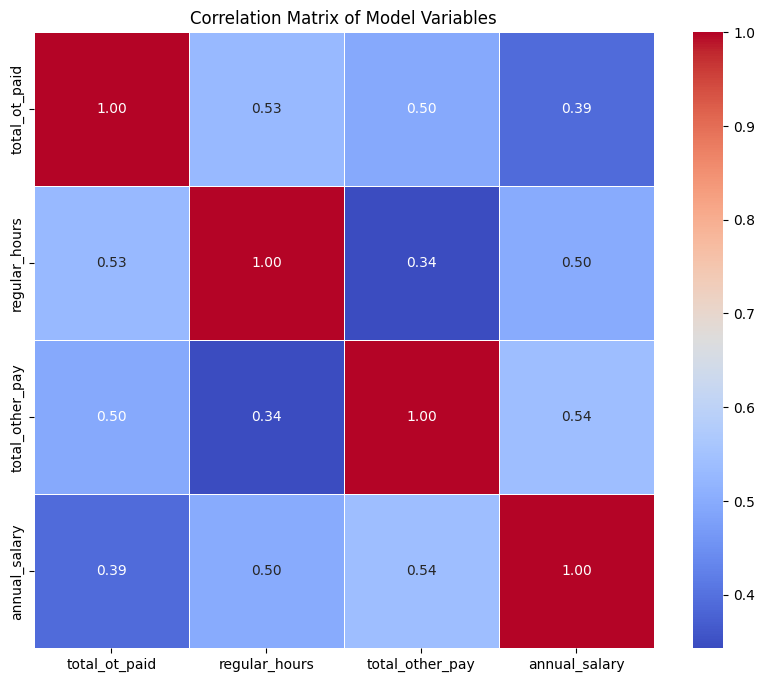

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the variables for the correlation matrix
correlation_vars = ['total_ot_paid', 'regular_hours', 'total_other_pay', 'annual_salary']
corr_df = merged[correlation_vars].dropna() # Drop NaNs to ensure accurate correlation calculation

# Calculate the correlation matrix
correlation_matrix = corr_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Model Variables')
plt.show()

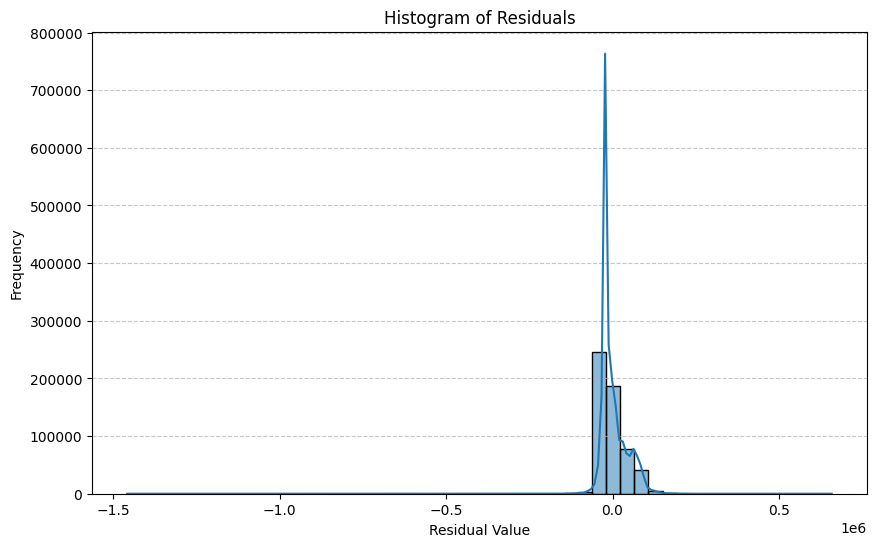

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Extract residuals from the new model results
residuals = results_new.resid

# Plotting the histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Figure size 800x600 with 0 Axes>

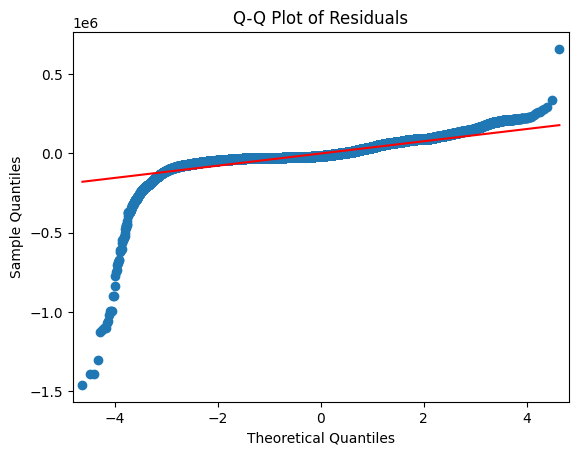

In [33]:
# Plotting the Q-Q plot of residuals
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='s') # 's' for standardized line
plt.title('Q-Q Plot of Residuals')
plt.show()

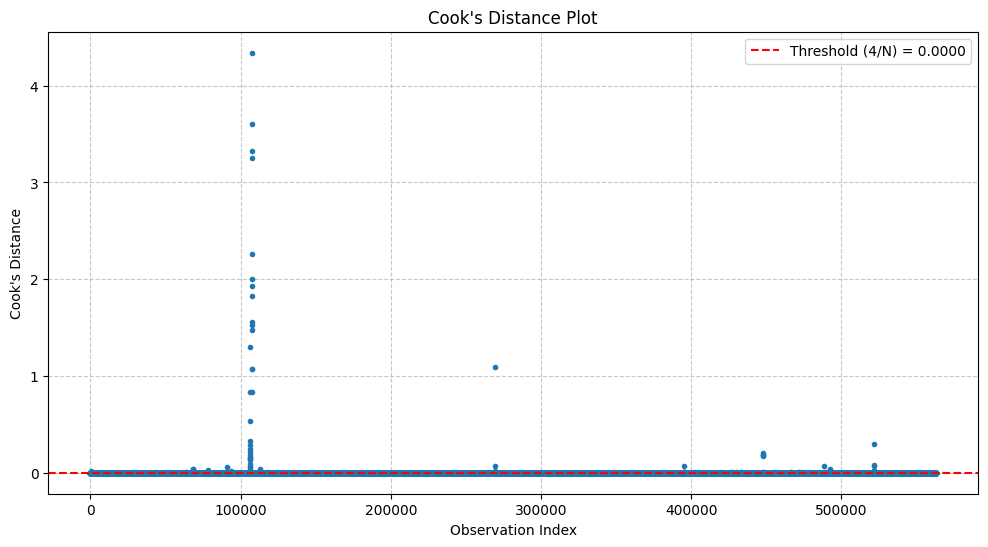


Number of influential points (Cook's Distance > 0.0000): 20344


,fiscal_year,payroll_number,agency_name,last_name,first_name,mid_init,agency_start_date,work_location_borough,title_description,leave_status_as_of_june_30,base_salary,pay_basis,regular_hours,regular_gross_paid,ot_hours,total_ot_paid,total_other_pay,annual_salary,title,salary_band
41,2024,67,ADMIN FOR CHILDREN'S SVCS,CLARRY,TRACY,N,02/18/2014,QUEENS,EXECUTIVE AGENCY COUNSEL,ACTIVE,182329.0,per Annum,1820.0,189121.20,0,0.0,4380.21,189121.20,Executive Agency Counsel,High
144,2024,67,ADMIN FOR CHILDREN'S SVCS,HESTER,MELISSA,E,11/19/2018,MANHATTAN,ADMINISTRATIVE STAFF ANALYST,ACTIVE,264748.0,per Annum,1820.0,276949.22,0,0.0,4192.00,276949.22,Administrative Staff Analyst,High
214,2024,67,ADMIN FOR CHILDREN'S SVCS,HAUSLAIB,EDEN,NaN,09/06/2005,MANHATTAN,ADMINISTRATIVE DIRECTOR OF SOCIAL SERVICES,ACTIVE,225811.0,per Annum,1820.0,236429.98,0,0.0,4014.00,236429.98,Administrative Director Of Social Services,High
215,2024,67,ADMIN FOR CHILDREN'S SVCS,JONES,EVAN,C,01/02/2019,MANHATTAN,ADMINISTRATIVE STAFF ANALYST,ACTIVE,175562.0,per Annum,1820.0,182941.09,0,0.0,4014.00,182941.09,Administrative Staff Analyst,High
220,2024,67,ADMIN FOR CHILDREN'S SVCS,MARTIN,JACQUELINE,P,10/15/2001,MANHATTAN,ADMINISTRATIVE DIRECTOR OF SOCIAL SERVICES,ACTIVE,264835.0,per Annum,1820.0,277059.51,0,0.0,4000.00,277059.51,Administrative Director Of Social Services,High


In [34]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Calculate Cook's Distance
# results_new is the fitted OLS model from the previous steps
infl = results_new.get_influence()
cook_distance = infl.cooks_distance[0]

# Plot Cook's Distance
plt.figure(figsize=(12, 6))
plt.plot(cook_distance, marker='.', linestyle='')
plt.title("Cook's Distance Plot")
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")

# Add a threshold line (e.g., 4/N or 1) to identify influential points
# A common rule of thumb is to consider points with Cook's distance > 4/N as influential
threshold = 4 / len(merged) # N is the number of observations
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold (4/N) = {threshold:.4f}')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Identify and print observations with Cook's distance above the threshold
influential_points = merged.iloc[np.where(cook_distance > threshold)[0]]
print(f"\nNumber of influential points (Cook's Distance > {threshold:.4f}): {len(influential_points)}")
if not influential_points.empty:
    display(influential_points.head())
else:
    print("No influential points found above the threshold.")

## Report: Findings and Key Drivers of Annual Salary

This report summarizes the key insights derived from the exploratory data analysis (EDA) and the regression modeling conducted on the Citywide Payroll data, focusing on factors influencing `annual_salary`.

### 1. Annual Salary Distribution Overview

*   The `annual_salary` distribution showed a **right-skewed pattern**, indicating that a majority of employees fall into lower to mid-salary ranges, with a smaller number earning significantly higher salaries. This is typical for large organizational payrolls.
*   The data was categorized into four `salary_band`s (Low, Mid-Low, Mid-High, High) using quantiles, providing a stratified view of salary levels across the workforce.

### 2. Key Drivers from Exploratory Data Analysis (EDA)

#### A. High-Paying Titles

*   Analysis of average salaries revealed specific titles that command the highest compensation. The top 5 highest-paying titles were:
    *   **Chancellor**
    *   **Chief Actuary**
    *   **First Deputy Mayor**
    *   **Director Of Management & Budget**
    *   **Commissioner Of Labor Relations**

#### B. Agency-Level Salary Differences

*   When examining the distribution of `annual_salary` across agencies, we observed significant variations. Box plots for the top 10 agencies (by employee count) highlighted differences in median salaries and the spread of salaries within these major agencies. Some agencies exhibited a wider range of salaries, while others were more tightly clustered around a certain median.
*   The number of unique agencies in the dataset was 159, underscoring the diversity of employment within the city.

#### C. Correlation with Overtime Paid

*   An initial scatter plot and correlation analysis between `total_ot_paid` and `annual_salary` revealed a **moderate positive correlation of approximately 0.39**. This suggests that while there is a relationship, overtime pay alone is not a primary determinant of annual salary, and other factors are at play.

### 3. Key Drivers from Regression Analysis

To understand the combined impact of various factors on `annual_salary`, we employed both Ordinary Least Squares (OLS) and Robust Linear Model (RLM) regressions.

#### A. Initial OLS Model & Improvement

*   An initial OLS model using only `total_ot_paid` as a predictor explained only about 15.2% of the variance in `annual_salary`.
*   By including `regular_hours` and `total_other_pay` alongside `total_ot_paid`, the OLS model's explanatory power significantly increased to an **R-squared of 0.402**.

#### B. Addressing Outliers with Robust Linear Model (RLM)

*   The residuals of the improved OLS model showed **skewness and non-normality**, and Cook's Distance identified **20,344 influential points (outliers)**. These issues indicated that OLS estimates might be biased by extreme observations.
*   A **Robust Linear Model (RLM) with a HuberT estimator** was therefore implemented to reduce the influence of these outliers.

#### C. RLM Coefficients and Interpretation

Comparing OLS and RLM coefficients, the RLM provided more stable estimates:

*   **`const` (Intercept):** The OLS intercept was ~26,232, while the RLM intercept was significantly lower at ~14,961. This change suggests that after accounting for the robust handling of outliers, the baseline annual salary when other predictors are zero is estimated to be lower.
*   **`total_ot_paid`:** The OLS model showed a small negative coefficient (~-0.023), while the RLM model exhibited a more pronounced negative coefficient (~-0.093). This counter-intuitive negative relationship (more overtime, slightly lower annual salary, *ceteris paribus*) requires further investigation, but the RLM's stronger negative value indicates that outliers might have suppressed this effect in the OLS model.
*   **`regular_hours`:** Both models showed a strong positive and significant relationship. The RLM coefficient (~18.84) was slightly lower than OLS (~20.07), indicating that for each additional regular hour worked, the annual salary increases by approximately $18.84, with RLM providing a more robust estimate.
*   **`total_other_pay`:** Both models showed a strong positive and significant relationship. The RLM coefficient (~3.15) was higher than OLS (~2.15). This suggests that `total_other_pay` contributes significantly to `annual_salary`, and the RLM estimates a greater impact per dollar of other pay.

#### D. RLM Residual Analysis

*   The histogram and Q-Q plot of the RLM residuals indicated an improved distribution compared to OLS, with less skewness and closer alignment to normality. This demonstrates the effectiveness of robust regression in handling the non-ideal characteristics of the error term in the presence of outliers.

### Conclusion

The analysis reveals that `regular_hours` and `total_other_pay` are strong positive drivers of `annual_salary`, with `regular_hours` having the largest coefficient. The relationship with `total_ot_paid` is complex and negative in both models, but stronger in the RLM. The use of a Robust Linear Model was crucial in mitigating the impact of numerous outliers, leading to more reliable coefficient estimates for the key drivers of annual salary within the city's payroll data.